# 04 - Backtest Results

This notebook summarizes the first complete trading experiment of the project.

It compares transparent rule-based strategies with the DMN-lite model trained in notebook 03. The objective is not to claim a final production strategy, but to verify that the pipeline can transform the data and CPD features into positions, portfolio returns and risk-adjusted metrics.

In [1]:
import sys
from pathlib import Path

sys.modules.setdefault("numexpr", None)
sys.modules.setdefault("bottleneck", None)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT))

DATA_DIR = PROJECT_ROOT / "data" / "processed" / "stoxx600"
plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({"figure.figsize": (13, 5), "figure.dpi": 110})

## Reproducible Backtest Command

The source of truth is `scripts/04_run_backtest.py`. The optional cell below reruns the full comparison using the positions exported by notebook 03.

In [2]:
RUN_BACKTEST = False

if RUN_BACKTEST:
    import subprocess
    subprocess.run(
        [
            sys.executable,
            str(PROJECT_ROOT / "scripts" / "04_run_backtest.py"),
            "--positions-file",
            "dmn_lite_positions.csv",
            "--out-returns",
            "backtest_returns_with_dmn.csv",
            "--out-summary",
            "backtest_summary_with_dmn.csv",
        ],
        cwd=PROJECT_ROOT,
        check=True,
    )

## Performance Summary

All strategies are evaluated after transaction costs and portfolio-level volatility scaling. The rule-based strategies start after enough lookback history is available; DMN-lite starts in 2010 because it needs an initial training window.

In [3]:
summary = pd.read_csv(DATA_DIR / "backtest_summary_with_dmn.csv", parse_dates=["start_date", "end_date"])
display_cols = ["strategy", "start_date", "end_date", "ann_return", "ann_vol", "sharpe", "sortino", "calmar", "max_drawdown", "hit_ratio", "avg_assets", "avg_turnover"]
pretty = summary[display_cols].copy()
for col in ["ann_return", "ann_vol", "max_drawdown", "hit_ratio", "avg_turnover"]:
    pretty[col] = pretty[col].map(lambda x: f"{x:.2%}")
for col in ["sharpe", "sortino", "calmar", "avg_assets"]:
    pretty[col] = pretty[col].map(lambda x: f"{x:.2f}")
pretty

,strategy,start_date,end_date,ann_return,ann_vol,sharpe,sortino,calmar,max_drawdown,hit_ratio,avg_assets,avg_turnover
0,dmn_lite,2010-01-04,2026-04-10,3.08%,7.69%,0.43,0.54,0.15,-20.52%,53.27%,317.89,3.36%
1,slow_momentum,2006-12-21,2026-04-10,3.75%,14.73%,0.32,0.42,0.11,-34.29%,53.00%,251.34,4.19%
2,cpd_adjusted,2006-12-21,2026-04-10,3.69%,14.64%,0.32,0.41,0.11,-33.86%,52.96%,251.29,4.25%
3,slow_fast,2006-12-21,2026-04-10,1.68%,12.91%,0.19,0.24,0.05,-33.68%,53.30%,251.29,4.53%


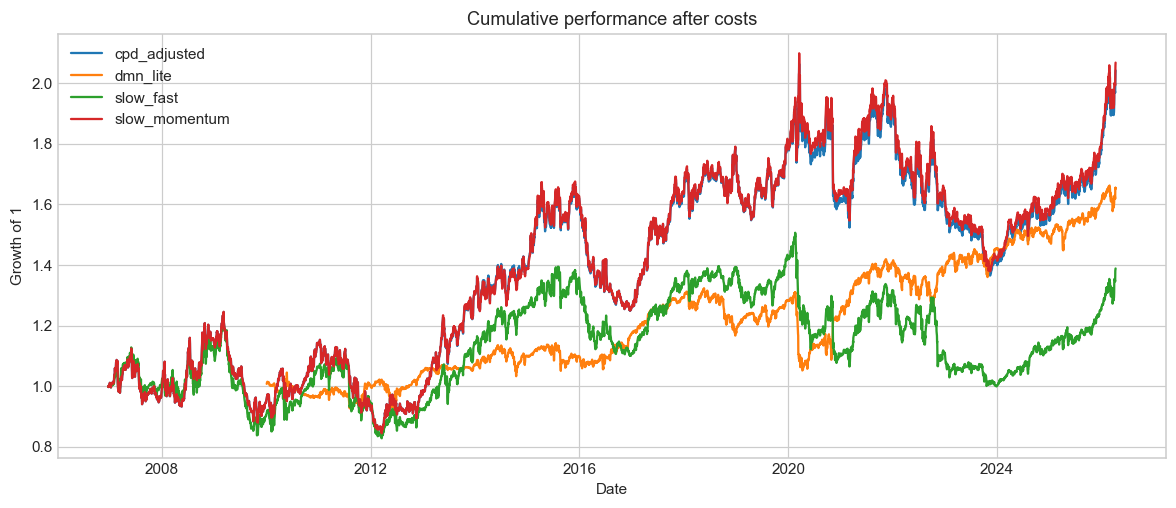

In [4]:
returns = pd.read_csv(DATA_DIR / "backtest_returns_with_dmn.csv", parse_dates=["date"])
returns["equity"] = returns.groupby("strategy")["net_return"].transform(lambda x: (1.0 + x.fillna(0.0)).cumprod())

fig, ax = plt.subplots()
for strategy, group in returns.groupby("strategy"):
    ax.plot(group["date"], group["equity"], label=strategy)
ax.set_title("Cumulative performance after costs")
ax.set_xlabel("Date")
ax.set_ylabel("Growth of 1")
ax.legend()
plt.show()

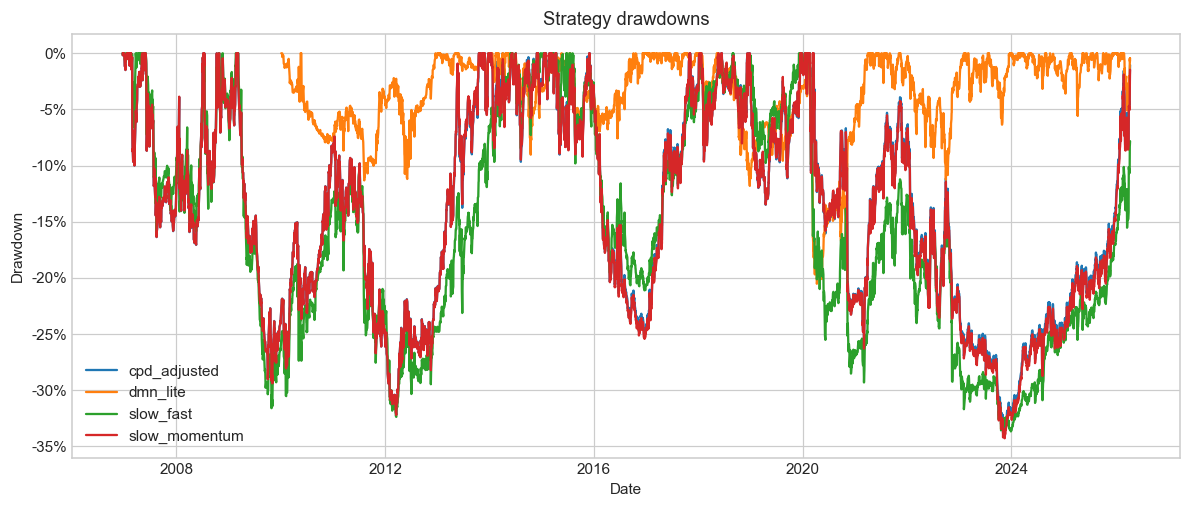

In [5]:
drawdowns = []
for strategy, group in returns.groupby("strategy"):
    equity = group["equity"]
    dd = equity / equity.cummax() - 1.0
    drawdowns.append(pd.DataFrame({"date": group["date"], "strategy": strategy, "drawdown": dd}))
drawdowns = pd.concat(drawdowns, ignore_index=True)

fig, ax = plt.subplots()
for strategy, group in drawdowns.groupby("strategy"):
    ax.plot(group["date"], group["drawdown"], label=strategy)
ax.set_title("Strategy drawdowns")
ax.set_xlabel("Date")
ax.set_ylabel("Drawdown")
ax.yaxis.set_major_formatter(lambda x, pos: f"{x:.0%}")
ax.legend()
plt.show()

## Current Reading

The DMN-lite model improves the Sharpe ratio and reduces drawdown versus the simple momentum baselines on its out-of-sample period. The result is encouraging, but it should be presented as preliminary because the true LSTM architecture and direct Sharpe-loss training still remain to be implemented.